# Deep Learning-Based Motion Deblurring and Number Recognition

## 1. Install the libraries

Run this cell once. Restart the notebook kernel if VS Code asks you to do so.

In [ ]:
%pip install torch torchvision pillow numpy pandas matplotlib scikit-image opencv-python pytesseract ultralytics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import libraries and choose folders

In [ ]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from skimage.metrics import peak_signal_noise_ratio, structural_similarity

random.seed(42)
torch.manual_seed(42)

PROJECT_FOLDER = Path.cwd() / 'Wagon Dataset'
if not PROJECT_FOLDER.exists():
    PROJECT_FOLDER = Path(r'd:\B.Tech\7th Sem\Minor Project\Wagon Dataset')

INPUT_FOLDER = PROJECT_FOLDER / 'input'
TARGET_FOLDER = PROJECT_FOLDER / 'output'
RESTORED_FOLDER = PROJECT_FOLDER / 'restored'
MODEL_FOLDER = PROJECT_FOLDER / 'models'
RESTORED_FOLDER.mkdir(exist_ok=True)
MODEL_FOLDER.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Input folder:', INPUT_FOLDER)
print('Device:', DEVICE)

## 2. Dataset organization and validation

The current dataset contains paired files: `input` is the blurred image and `output` is the sharp target. This stage checks the pairs, records image information, and creates a reproducible train/validation/test split. No model is trained yet.

In [ ]:
input_files = sorted(INPUT_FOLDER.glob('*.png'))
target_files = sorted(TARGET_FOLDER.glob('*.png'))
target_names = {path.name for path in target_files}
input_names = {path.name for path in input_files}

missing_targets = sorted(input_names - target_names)
missing_inputs = sorted(target_names - input_names)
pairs = []
metadata_rows = []

for input_path in input_files:
    target_path = TARGET_FOLDER / input_path.name
    if not target_path.exists():
        continue

    with Image.open(input_path) as input_image:
        input_width, input_height = input_image.size
    with Image.open(target_path) as target_image:
        target_width, target_height = target_image.size

    pairs.append((input_path, target_path))
    metadata_rows.append({
        'filename': input_path.name,
        'input_path': str(input_path),
        'target_path': str(target_path),
        'input_width': input_width,
        'input_height': input_height,
        'target_width': target_width,
        'target_height': target_height,
        'same_size': (input_width == target_width and input_height == target_height)
    })

if len(pairs) == 0:
    raise FileNotFoundError('No matching input/output image pairs were found.')

metadata = pd.DataFrame(metadata_rows)
metadata = metadata.sample(frac=1, random_state=42).reset_index(drop=True)
metadata['split'] = 'train'
validation_start = int(len(metadata) * 0.8)
test_start = int(len(metadata) * 0.9)
metadata.loc[validation_start:test_start - 1, 'split'] = 'validation'
metadata.loc[test_start:, 'split'] = 'test'

metadata_path = PROJECT_FOLDER / 'dataset_index.csv'
metadata.to_csv(metadata_path, index=False)

print('Input images:', len(input_files))
print('Target images:', len(target_files))
print('Valid pairs:', len(pairs))
print('Missing targets:', len(missing_targets))
print('Missing inputs:', len(missing_inputs))
print('Different-size pairs:', int((~metadata['same_size']).sum()))
print('Train:', int((metadata['split'] == 'train').sum()))
print('Validation:', int((metadata['split'] == 'validation').sum()))
print('Test:', int((metadata['split'] == 'test').sum()))
print('Dataset index saved to:', metadata_path)

if missing_targets:
    print('First missing target:', missing_targets[0])
if missing_inputs:
    print('First missing input:', missing_inputs[0])

Input images: 252
Target images: 252
Valid pairs: 252
Missing targets: 0
Missing inputs: 0
Different-size pairs: 0
Train: 201
Validation: 25
Test: 26
Dataset index saved to: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\dataset_index.csv


### 2.1 Save split manifests

These CSV files point to the original images. They avoid copying the same images into multiple folders and will be used by later training stages.

In [ ]:
for split_name in ['train', 'validation', 'test']:
    split_rows = metadata[metadata['split'] == split_name].copy()
    split_path = PROJECT_FOLDER / (split_name + '_pairs.csv')
    split_rows.to_csv(split_path, index=False)
    print(split_name, 'manifest:', split_path, 'rows:', len(split_rows))

train manifest: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\train_pairs.csv rows: 201
validation manifest: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\validation_pairs.csv rows: 25
test manifest: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\test_pairs.csv rows: 26


### 2.2 Inspect image quality

This quick visual check helps us catch incorrect pairs, unreadable files, and extreme brightness differences before training.

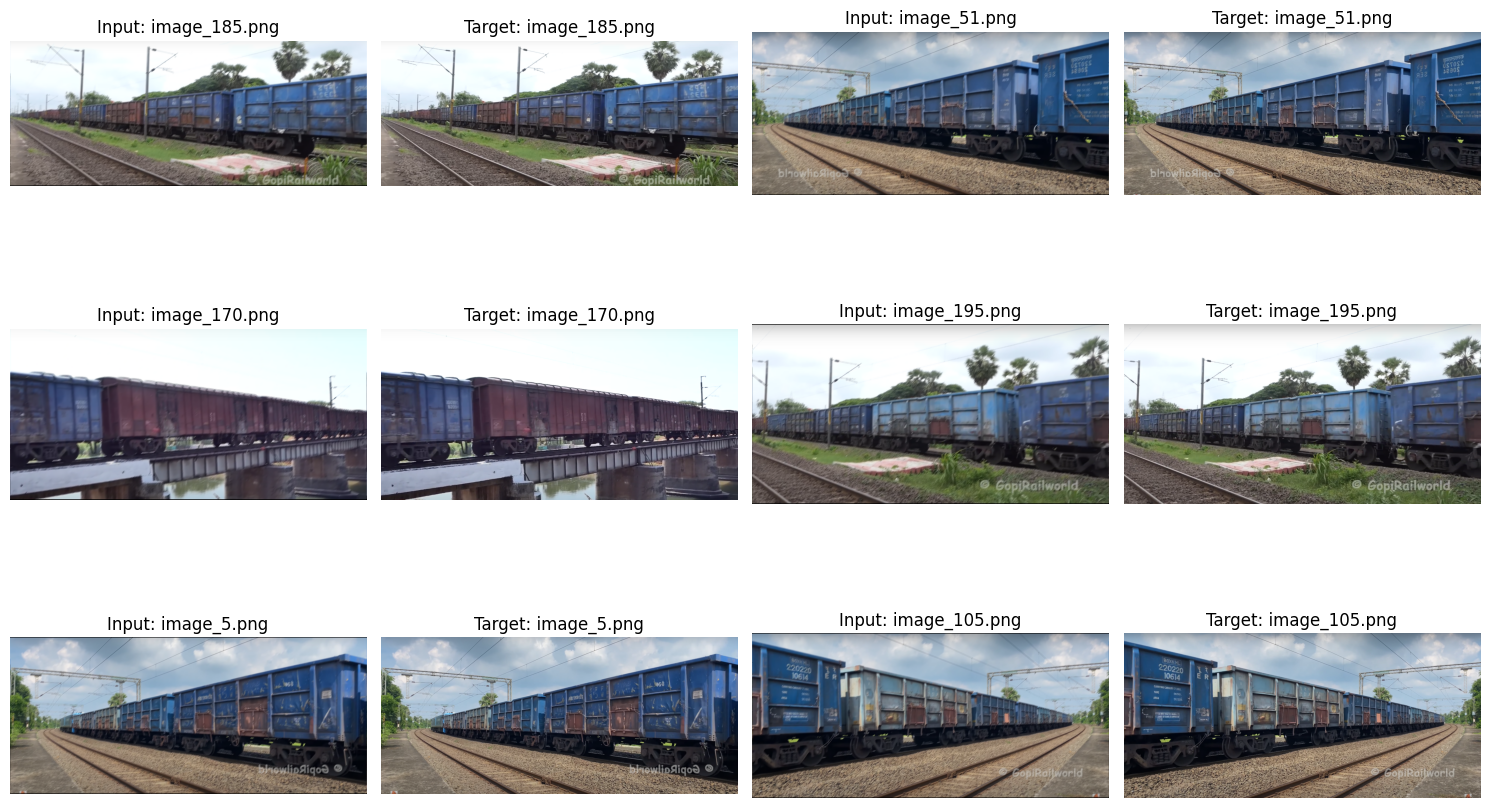

     filename  input_mean_brightness  target_mean_brightness
image_185.png                 138.16                  139.76
 image_51.png                 114.27                  115.43
image_170.png                 140.75                  142.48
image_195.png                 135.09                  136.41
  image_5.png                 115.54                  116.83
image_105.png                 115.56                  116.73


In [ ]:
sample_rows = metadata.sample(n=min(6, len(metadata)), random_state=42)
brightness_rows = []

plt.figure(figsize=(15, 10))
for plot_number, (_, row) in enumerate(sample_rows.iterrows(), start=1):
    input_image = Image.open(row['input_path']).convert('RGB')
    target_image = Image.open(row['target_path']).convert('RGB')
    input_array = np.asarray(input_image).astype(np.float32)
    target_array = np.asarray(target_image).astype(np.float32)
    brightness_rows.append({
        'filename': row['filename'],
        'input_mean_brightness': round(float(input_array.mean()), 2),
        'target_mean_brightness': round(float(target_array.mean()), 2)
    })

    plt.subplot(3, 4, plot_number * 2 - 1)
    plt.imshow(input_image)
    plt.title('Input: ' + row['filename'])
    plt.axis('off')
    plt.subplot(3, 4, plot_number * 2)
    plt.imshow(target_image)
    plt.title('Target: ' + row['filename'])
    plt.axis('off')

plt.tight_layout()
plt.show()

brightness = pd.DataFrame(brightness_rows)
print(brightness.to_string(index=False))

## 3. Prepare YOLO annotation files

The current images do not contain bounding-box labels. This cell creates the folders and templates needed for manual annotation. Do not train YOLO until the box coordinates are filled in.

In [ ]:
YOLO_ROOT = PROJECT_FOLDER / 'yolo_wagon'
for folder in [
    YOLO_ROOT / 'images' / 'train',
    YOLO_ROOT / 'images' / 'validation',
    YOLO_ROOT / 'images' / 'test',
    YOLO_ROOT / 'labels' / 'train',
    YOLO_ROOT / 'labels' / 'validation',
    YOLO_ROOT / 'labels' / 'test'
]:
    folder.mkdir(parents=True, exist_ok=True)

classes_path = YOLO_ROOT / 'classes.txt'
classes_path.write_text('wagon\n', encoding='utf-8')

annotation_template = metadata[['filename', 'input_width', 'input_height', 'split']].copy()
annotation_template['class_name'] = ''
annotation_template['x_min'] = ''
annotation_template['y_min'] = ''
annotation_template['x_max'] = ''
annotation_template['y_max'] = ''
annotation_template['annotation_status'] = 'not_annotated'
annotation_template_path = PROJECT_FOLDER / 'wagon_annotations_template.csv'
annotation_template.to_csv(annotation_template_path, index=False)

print('YOLO folders created at:', YOLO_ROOT)
print('Class file:', classes_path)
print('Annotation template:', annotation_template_path)
print('Images still need to be labeled before YOLO training.')

YOLO folders created at: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon
Class file: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon\classes.txt
Annotation template: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\wagon_annotations_template.csv
Images still need to be labeled before YOLO training.


### 3.1 Create a coordinate preview

Use the pixel axes in this preview when filling the annotation template. The first YOLO model will label complete wagons; number-region labels will be prepared separately later.

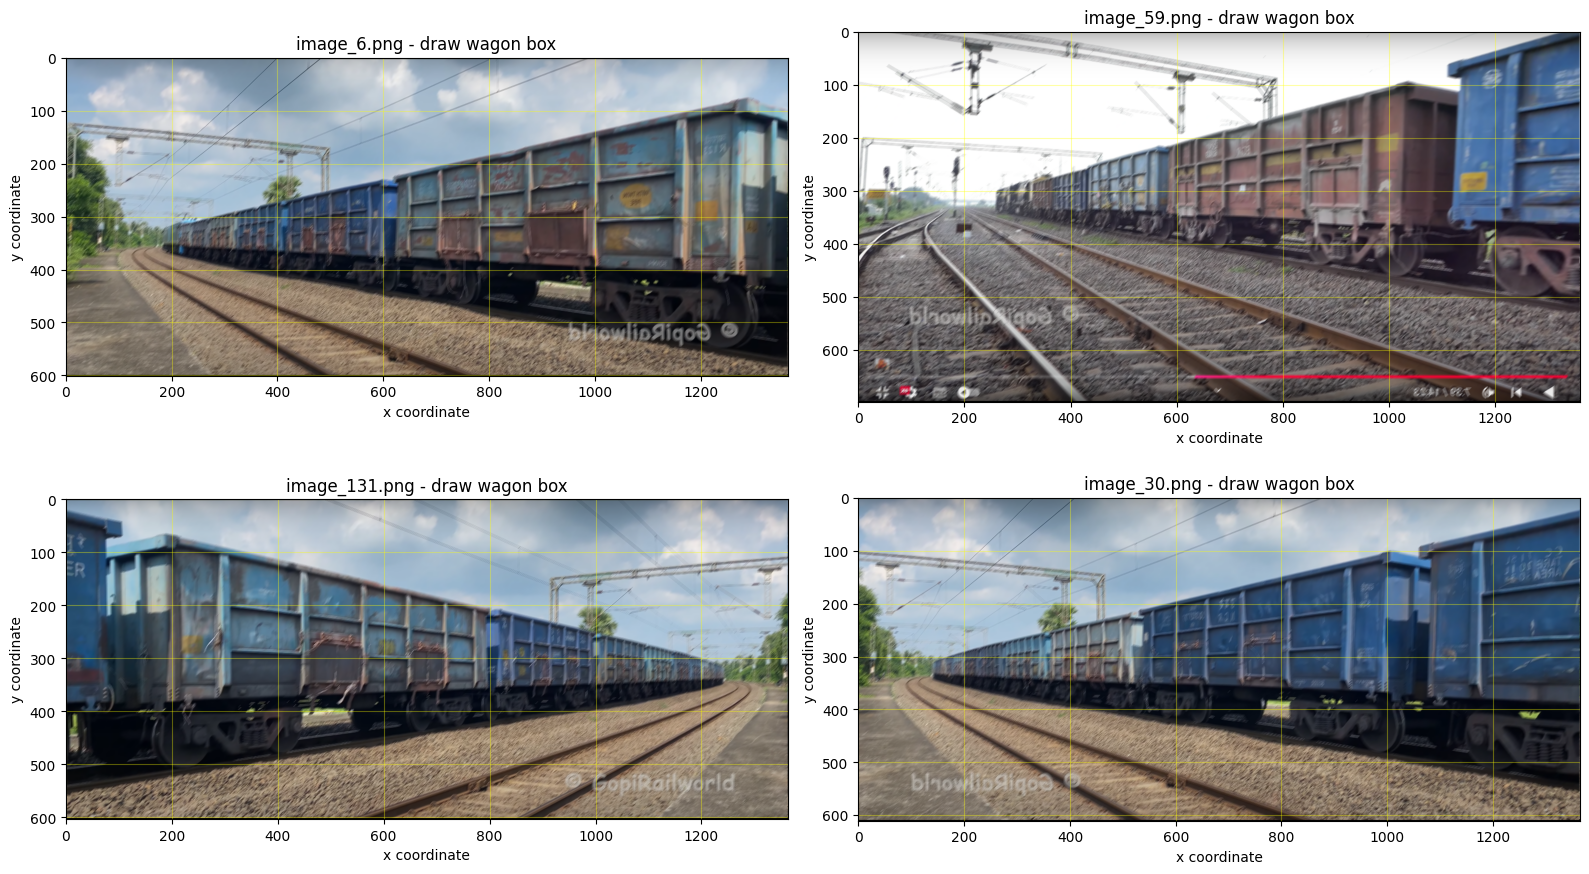

Preview saved to: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_annotation_preview.png


In [ ]:
preview_rows = metadata.sample(n=min(4, len(metadata)), random_state=7)
plt.figure(figsize=(16, 9))

for plot_number, (_, row) in enumerate(preview_rows.iterrows(), start=1):
    image = Image.open(row['input_path']).convert('RGB')
    plt.subplot(2, 2, plot_number)
    plt.imshow(image)
    plt.title(row['filename'] + ' - draw wagon box')
    plt.xlabel('x coordinate')
    plt.ylabel('y coordinate')
    plt.grid(color='yellow', alpha=0.35)

plt.tight_layout()
preview_path = PROJECT_FOLDER / 'yolo_annotation_preview.png'
plt.savefig(preview_path, dpi=150)
plt.show()
print('Preview saved to:', preview_path)

## 4. Copy images and create YOLO wagon labels

This stage copies images into their split folders and provides a small function for saving manually measured wagon boxes in YOLO format. The coordinates must come from the preview or an annotation tool.

In [ ]:
import shutil

for _, row in metadata.iterrows():
    split_name = row['split']
    destination = YOLO_ROOT / 'images' / split_name / row['filename']
    shutil.copy2(row['input_path'], destination)

print('Copied images:', len(metadata))
print('Use class 0 for every wagon box.')

Copied images: 252
Use class 0 for every wagon box.


In [ ]:
def pixel_box_to_yolo(x_min, y_min, x_max, y_max, image_width, image_height):
    x_min = max(0, min(float(x_min), image_width))
    y_min = max(0, min(float(y_min), image_height))
    x_max = max(0, min(float(x_max), image_width))
    y_max = max(0, min(float(y_max), image_height))

    if x_max <= x_min or y_max <= y_min:
        raise ValueError('The box must have positive width and height.')

    box_width = x_max - x_min
    box_height = y_max - y_min
    center_x = x_min + box_width / 2
    center_y = y_min + box_height / 2

    return (
        center_x / image_width,
        center_y / image_height,
        box_width / image_width,
        box_height / image_height
    )


def save_wagon_labels(filename, boxes):
    image_path = INPUT_FOLDER / filename
    if not image_path.exists():
        raise FileNotFoundError('Image not found: ' + str(image_path))

    with Image.open(image_path) as image:
        image_width, image_height = image.size

    yolo_boxes = []
    for box in boxes:
        values = pixel_box_to_yolo(*box, image_width, image_height)
        yolo_boxes.append('0 ' + ' '.join(f'{value:.6f}' for value in values))

    split_name = metadata.loc[metadata['filename'] == filename, 'split'].iloc[0]
    label_path = YOLO_ROOT / 'labels' / split_name / (Path(filename).stem + '.txt')
    label_path.write_text('\n'.join(yolo_boxes) + '\n', encoding='utf-8')
    print('Saved', len(boxes), 'wagon box(es) to:', label_path)

print('Function ready.')
print("Example: save_wagon_labels('image_1.png', [(100, 120, 1300, 460)])")

Function ready.
Example: save_wagon_labels('image_1.png', [(100, 120, 1300, 460)])


### How to annotate one image

1. Open `yolo_annotation_preview.png` or the original image.
2. Record each wagon box as `(x_min, y_min, x_max, y_max)` in pixels.
3. Run, for example:

```python
save_wagon_labels('image_1.png', [(100, 120, 1300, 460)])
```

For multiple wagons, add multiple boxes inside the list. Repeat this for the images selected for YOLO training.

In [ ]:
def check_yolo_labels():
    label_count = 0
    invalid_lines = []

    for label_path in YOLO_ROOT.glob('labels/*/*.txt'):
        label_count += 1
        for line_number, line in enumerate(label_path.read_text(encoding='utf-8').splitlines(), start=1):
            parts = line.split()
            if len(parts) != 5:
                invalid_lines.append(str(label_path) + ':' + str(line_number))
                continue
            values = [float(value) for value in parts[1:]]
            if parts[0] != '0' or any(value < 0 or value > 1 for value in values):
                invalid_lines.append(str(label_path) + ':' + str(line_number))

    print('Label files found:', label_count)
    print('Invalid label lines:', len(invalid_lines))
    if invalid_lines:
        print('First invalid line:', invalid_lines[0])

print('Run check_yolo_labels() after adding annotations.')

Run check_yolo_labels() after adding annotations.


## 5. Train the YOLO wagon detector

YOLO training requires label files in `yolo_wagon/labels`. The following cells prepare Ultralytics YOLO and refuse to start if labels are missing.

In [ ]:
%pip install ultralytics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
yolo_data_yaml = YOLO_ROOT / 'data.yaml'
yolo_root_text = YOLO_ROOT.as_posix()
yolo_data_yaml.write_text(
    'path: ' + yolo_root_text + '\n'
    'train: images/train\n'
    'val: images/validation\n'
    'test: images/test\n'
    'names:\n'
    '  0: wagon\n',
    encoding='utf-8'
)

label_files = list((YOLO_ROOT / 'labels').glob('*/*.txt'))
print('YOLO data file:', yolo_data_yaml)
print('Label files available:', len(label_files))

YOLO data file: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon\data.yaml
Label files available: 252


In [ ]:
def train_wagon_detector():
    label_files = list((YOLO_ROOT / 'labels').glob('*/*.txt'))
    if len(label_files) == 0:
        print('YOLO training skipped: annotate wagons first, then run this cell again.')
        return None

    from ultralytics import YOLO

    training_device = 0 if torch.cuda.is_available() else 'cpu'
    yolo_model = YOLO('yolov8n.pt')
    yolo_model.train(
        data=str(yolo_data_yaml),
        epochs=50,
        imgsz=640,
        batch=2,
        workers=2,
        cache=False,
        amp=True,
        project=str(PROJECT_FOLDER / 'yolo_runs'),
        name='wagon_detector',
        device=training_device
    )
    print('Training completed.')
    return yolo_model


yolo_model = train_wagon_detector()

Ultralytics 8.4.155  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scal

In [ ]:
if yolo_model is not None:
    test_image_count = len(list((YOLO_ROOT / 'images' / 'test').glob('*.*')))
    evaluation_split = 'test' if test_image_count > 0 else 'val'
    validation_results = yolo_model.val(
        data=str(yolo_data_yaml),
        split=evaluation_split,
        imgsz=640,
        batch=1,
        workers=2,
        device=0 if torch.cuda.is_available() else 'cpu'
    )
    print('Evaluation split:', evaluation_split)
    print('Evaluation completed.')
else:
    print('Run the training cell after adding labels.')

Ultralytics 8.4.155  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1862.3179.8 MB/s, size: 1447.9 KB)
val: Scanning D:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon\labels\validation.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9s/it 3.7s<11.8s
                   all         20         20      0.997          1      0.995      0.893
Speed: 1.3ms preprocess, 10.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to D:\B.Tech\7th Sem\Minor Project\runs\detect\val-2
Evaluation split: val
Evaluation completed.


## 6. Prepare number-region annotations

The second YOLO model detects only the small printed number area inside a wagon. These labels are separate from the complete-wagon labels used in Stage 4.

In [ ]:
NUMBER_YOLO_ROOT = PROJECT_FOLDER / 'yolo_number'
for folder in [
    NUMBER_YOLO_ROOT / 'images' / 'train',
    NUMBER_YOLO_ROOT / 'images' / 'validation',
    NUMBER_YOLO_ROOT / 'images' / 'test',
    NUMBER_YOLO_ROOT / 'labels' / 'train',
    NUMBER_YOLO_ROOT / 'labels' / 'validation',
    NUMBER_YOLO_ROOT / 'labels' / 'test'
]:
    folder.mkdir(parents=True, exist_ok=True)

for _, row in metadata.iterrows():
    destination = NUMBER_YOLO_ROOT / 'images' / row['split'] / row['filename']
    shutil.copy2(row['input_path'], destination)

number_classes_path = NUMBER_YOLO_ROOT / 'classes.txt'
number_classes_path.write_text('number_region\n', encoding='utf-8')

number_data_yaml = NUMBER_YOLO_ROOT / 'data.yaml'
number_data_yaml.write_text(
    'path: ' + NUMBER_YOLO_ROOT.as_posix() + '\n'
    'train: images/train\n'
    'val: images/validation\n'
    'test: images/test\n'
    'names:\n'
    '  0: number_region\n',
    encoding='utf-8'
)

print('Number-region dataset created at:', NUMBER_YOLO_ROOT)
print('Images copied:', len(metadata))
print('Number class file:', number_classes_path)
print('Labels still need manual annotation.')

Number-region dataset created at: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_number
Images copied: 252
Number class file: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_number\classes.txt
Labels still need manual annotation.


In [ ]:
def save_number_labels(filename, boxes):
    image_path = INPUT_FOLDER / filename
    if not image_path.exists():
        raise FileNotFoundError('Image not found: ' + str(image_path))

    with Image.open(image_path) as image:
        image_width, image_height = image.size

    yolo_boxes = []
    for box in boxes:
        values = pixel_box_to_yolo(*box, image_width, image_height)
        yolo_boxes.append('0 ' + ' '.join(f'{value:.6f}' for value in values))

    split_name = metadata.loc[metadata['filename'] == filename, 'split'].iloc[0]
    label_path = NUMBER_YOLO_ROOT / 'labels' / split_name / (Path(filename).stem + '.txt')
    label_path.write_text('\n'.join(yolo_boxes) + '\n', encoding='utf-8')
    print('Saved', len(boxes), 'number-region box(es) to:', label_path)


def count_number_labels():
    label_files = list((NUMBER_YOLO_ROOT / 'labels').glob('*/*.txt'))
    print('Number-region label files:', len(label_files))
    return len(label_files)

print("Example: save_number_labels('image_1.png', [(700, 180, 850, 250)])")
print('Use one box around each visible printed wagon number.')

Example: save_number_labels('image_1.png', [(700, 180, 850, 250)])
Use one box around each visible printed wagon number.
